<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/03_weight_init_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Weight Initialization Techniques — Keras

Before training, every weight needs a starting value. Bad initialization can stall learning entirely (all-zeros) or cause exploding/vanishing signals. We compare **Zeros, Random Normal, Glorot/Xavier, and He**.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. Why initialization matters
- **Zeros:** every neuron computes the same thing and receives the same gradient → they can never differentiate. This is the classic *symmetry* failure.
- **Random Normal (large):** breaks symmetry but can make activations explode or vanish across layers.
- **Glorot / Xavier:** variance scaled by fan-in + fan-out — designed for `tanh`/`sigmoid`.
- **He:** variance scaled by fan-in — designed for `ReLU` (our hidden activation).

We use a slightly **deeper** net (3 hidden layers) so the initialization effect is visible.

In [5]:
def build_and_train(initializer, epochs=100):
    keras.utils.set_random_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(32, activation="relu", kernel_initializer=initializer),
        layers.Dense(32, activation="relu", kernel_initializer=initializer),
        layers.Dense(16, activation="relu", kernel_initializer=initializer),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.SGD(0.05),
                  loss="binary_crossentropy", metrics=["accuracy"])
    hist = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                     epochs=epochs, batch_size=32, verbose=0)
    return hist

initializers = {
    "Zeros":         "zeros",
    "Random Normal": keras.initializers.RandomNormal(stddev=1.0),
    "Glorot/Xavier": "glorot_uniform",
    "He":            "he_normal",
}

results = {}
for name, init in initializers.items():
    results[name] = build_and_train(init)
    h = results[name].history
    print("%-14s final test acc = %.3f | final test loss = %.3f" %
          (name, h["val_accuracy"][-1], h["val_loss"][-1]))

Zeros          final test acc = 0.691 | final test loss = 0.618


Random Normal  final test acc = 0.837 | final test loss = 0.421


Glorot/Xavier  final test acc = 0.862 | final test loss = 0.402


He             final test acc = 0.846 | final test loss = 0.410


## 5. Comparison table

Notice how **Zeros** never gets off the ground — it just predicts the majority class.

In [6]:
summary = pd.DataFrame({
    name: {
        "final_train_acc": h.history["accuracy"][-1],
        "final_test_acc":  h.history["val_accuracy"][-1],
        "final_test_loss": h.history["val_loss"][-1],
    } for name, h in results.items()
}).T
summary.round(4)

,final_train_acc,final_test_acc,final_test_loss
Zeros,0.6864,0.6911,0.6183
Random Normal,0.8086,0.8374,0.4209
Glorot/Xavier,0.7984,0.8618,0.4024
He,0.8065,0.8455,0.4099


## 6. Overlaid learning curves

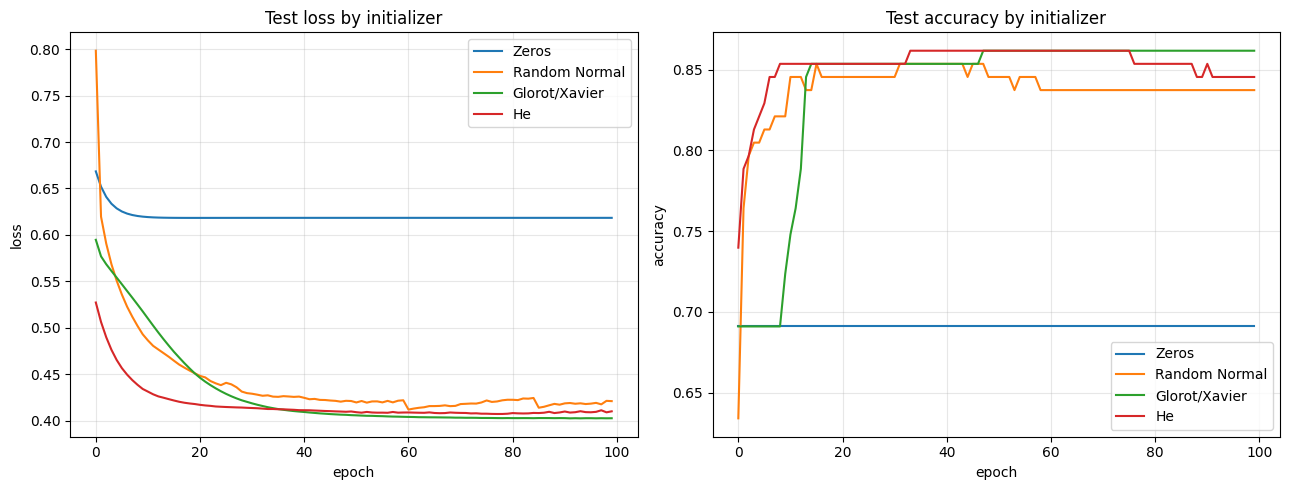

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, h in results.items():
    ax[0].plot(h.history["val_loss"], label=name)
    ax[1].plot(h.history["val_accuracy"], label=name)
ax[0].set_title("Test loss by initializer"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[1].set_title("Test accuracy by initializer"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways
- **Zeros** is a dead end: symmetric neurons never separate — the curve is flat.
- **Large Random Normal** trains but is unstable / slow because activations aren't variance-controlled.
- **Glorot** and **He** both train smoothly; **He** is the right theoretical match for ReLU layers and usually edges ahead in deeper ReLU nets.
- Rule of thumb: **He for ReLU, Glorot for tanh/sigmoid** — and never all-zeros for the weights.
- **Next:** `04_early_stopping_keras` — stop training at the right moment.